In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3.0)

20.0

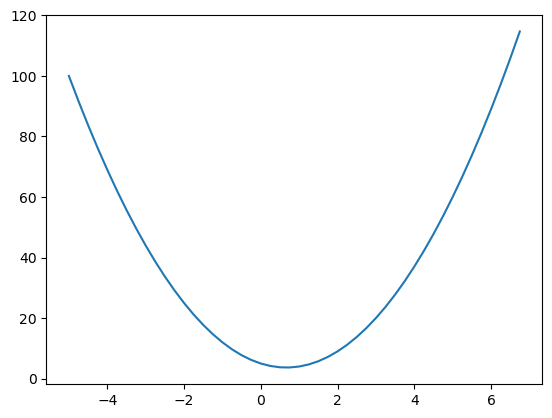

In [4]:
xs=np.arange(-5,7,0.25)
ys=f(xs)
plt.plot(xs,ys)
plt.show() 
#为什么需要plt.show()？
# 因为在某些环境中（如Jupyter Notebook）需要调用plt.show()来显示图形，而在其他环境中（如Python脚本）则不需要。
# plt.show()会阻止代码继续执行，直到图形窗口被关闭，这对于交互式环境非常有用。

In [5]:
h=0.0000001
x=2/3
print(f(x))
print(f(x+h))
print((f(x+h)-f(x))/h)

3.666666666666667
3.6666666666666967
2.9753977059954195e-07


In [6]:
# let grt more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [7]:
h=0.0001

a=2.0
b=-3.0
c=10.0
d1=a*b+c
print('d1=',d1)


# a+=h
# b+=h
c+=h

d2=a*b+c
print('d2=',d2)

print('slope=',(d2-d1)/h)



d1= 4.0
d2= 4.0001
slope= 0.9999999999976694


In [79]:
class Value:
    # __init__是一个特殊方法，用于在创建对象时初始化对象的属性。
    # self是一个指向当前对象的引用，允许我们在类的方法中访问对象的属性和方法。
    # 举例来说，当我们创建一个Value对象时，__init__方法会被自动调用，并且self参数会指向新创建的对象。我们可以使用self.data来存储传入的数据，并在其他方法中访问它。
    def __init__(self,data,_children=(),_op='',label=''): 
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label

    # __repr__是一个特殊方法，用于定义对象的字符串表示。
    # 当我们打印一个对象或者使用str()函数时，__repr__方法会被调用来返回一个字符串，描述这个对象的内容。
    def __repr__(self):
        return f"Value(data={self.data})"
    
    # def __str__(self):
    #     return f"Value(data={self.data})"

    def __add__(self,other):
        out=Value(self.data+other.data,(self,other),'+')

        def _backward():
            self.grad+=out.grad*1.0
            other.grad+=out.grad*1.0
        out._backward=_backward

        return out

    def __mul__(self,other):
        out=Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward

        return out

    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out
    
    def backward(self):
        
        topo=[]; 
        visited=set() 
        def build_topo(v): 
            if v not in visited: 
                visited.add(v) 
                for child in v._prev: 
                    build_topo(child) 
                topo.append(v) 
        build_topo(self) 

        self.grad=1.0
        for node in reversed(topo):
            node._backward()

a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b; e.label='e'
d=e+c; d.label='d'
f=Value(-2.0,label='f')
L=d*f; L.label='L'
L

Value(data=-8.0)

In [28]:
from graphviz import Digraph 
def trace(root): 
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR=left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

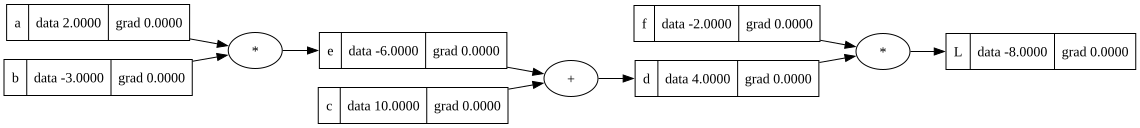

In [29]:
draw_dot(L)

In [30]:
L.grad=1.0
d.grad=-2.0
f.grad=4.0
e.grad=-2.0
c.grad=-2.0
a.grad=6.0
b.grad=-4.0



In [31]:
def lol():
    h=0.0001

    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e._label='e'
    d=e+c; d._label='d'
    f=Value(-2.0,label='f')
    L=d*f; L._label='L'
    L1=L.data

    a=Value(2.0,label='a')
    # a.data+=h
    b=Value(-3.0,label='b')
    b.data+=h
    c=Value(10.0,label='c')
    # c.data+=h
    e=a*b; e._label='e'
    # e.data+=h
    d=e+c; d._label='d'
    # d.data+=h
    f=Value(-2.0,label='f')
    # f.data+=h
    L=d*f; L._label='L'
    L2=L.data
    # L2+=h

    print((L2-L1)/h)

lol()

-4.000000000008441


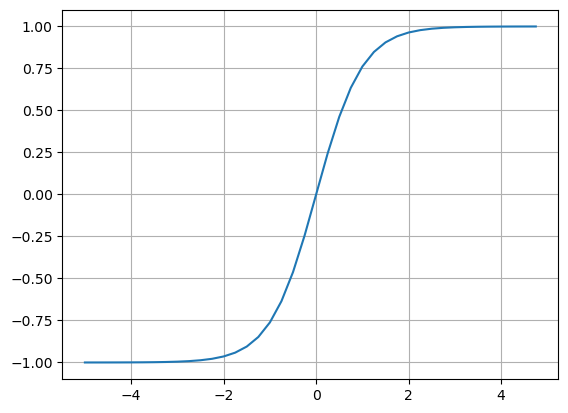

In [32]:
plt.plot(np.arange(-5.0,5.0,0.25),np.tanh(np.arange(-5.0,5.0,0.25)))
plt.grid(True)

In [86]:
x1= Value(2.0,label='x1')
x2= Value(0.0, label='x2')
w1= Value(-3.0,label='w1')
w2= Value(1.0,label='w2')
b= Value(6.8813735870195432,label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'


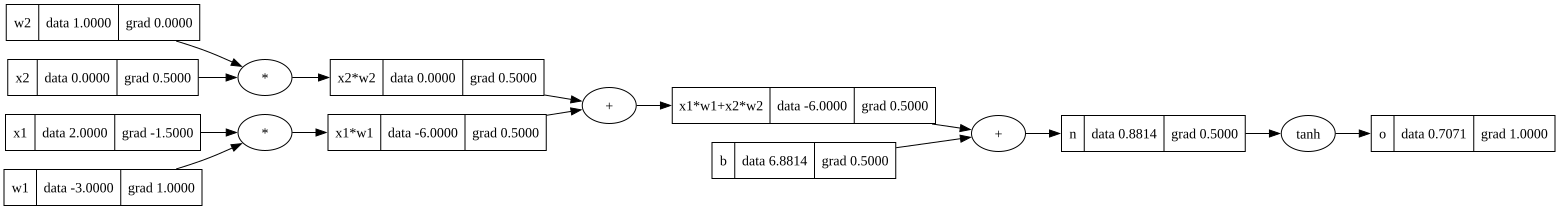

In [89]:
draw_dot(o)

In [88]:
o.backward()

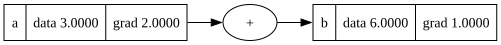

In [90]:
a=Value(3.0,label='a')
b=a+a; b.label='b'
b.backward()
draw_dot(b)

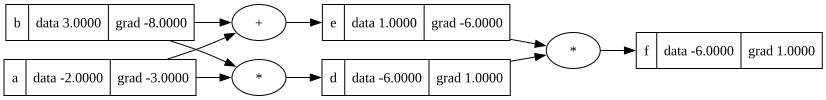

In [91]:
a=Value(-2.0,label='a') 
b=Value(3.0,label='b') 
d=a*b; d.label='d' 
e=a+b; e.label='e' 
f=d*e; f.label='f' 
f.backward() 
draw_dot(f)

In [71]:
o.grad=1.0

topo=[]; 
visited=set() 
def build_topo(v): 
    if v not in visited: 
        visited.add(v) 
        for child in v._prev: 
            build_topo(child) 
        topo.append(v) 
build_topo(o) 

for node in reversed(topo):
    node._backward()

In [66]:
topo=[]; 
visited=set() 
def build_topo(v): 
    if v not in visited: 
        visited.add(v) 
        for child in v._prev: 
            build_topo(child) 
        topo.append(v) 
build_topo(o) 
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [64]:
o.grad=1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [44]:
o.grad=1.0
n.grad=0.5
x1w1x2w2.grad=n.grad*1.0
b.grad=n.grad*1.0
x1w1.grad=x1w1x2w2.grad*1.0
x2w2.grad=x1w1x2w2.grad*1.0
x1.grad=x1w1.grad*w1.data
w1.grad=x1w1.grad*x1.data
x2.grad=x2w2.grad*w2.data
w2.grad=x2w2.grad*x2.data

# Python 学习笔记

## 1. `__repr__` vs `__str__`

两者都必须返回 `str` 类型，区别在于**约定用途**不同：

| 方法 | 用途 | 调用时机 | 惯例返回内容 |
|---|---|---|---|
| `__repr__` | 给**开发者**看，力求精确 | 交互式解释器、`repr(obj)`、容器内元素显示 | 能重建对象的表达式，如 `"Vaule(data=2.0)"` |
| `__str__` | 给**用户**看，力求可读 | `print(obj)`、`str(obj)`、f-string | 简洁友好的文本，如 `"2.0"` |

**注意**：如果没定义 `__str__`，Python 会**回退调用 `__repr__`**；反过来不行。所以优先实现 `__repr__`。

---

## 2. 下划线命名规则（`_` vs `__`）

Python 中下划线有三种不同含义：

| 写法 | 含义 | 例子 |
|---|---|---|
| `name`（无下划线） | **公开属性**，外部随便用 | `self.data`、`self.grad` |
| `_name`（单下划线） | **约定私有**，暗示"内部实现，外部最好别碰" | `self._prev`、`self._op` |
| `__name__`（双下划线包裹） | **Python 魔法方法**，有特殊语法含义 | `__init__`、`__add__`、`__repr__` |

### 常见魔法方法对应的语法：

| 魔法方法 | Python 自动调用时机 |
|---|---|
| `__init__` | 创建对象：`Vaule(2.0)` |
| `__repr__` | 打印/显示：`print(a)` 或交互式输入 `a` |
| `__add__` | 使用 `+`：`a + b` → `a.__add__(b)` |
| `__mul__` | 使用 `*`：`a * b` → `a.__mul__(b)` |

---

## 3. `_children` 与 `_prev`（计算图）

```python
def __init__(self, data, _children=(), _op='', _label=''):
    self.data = data
    self._prev = set(_children)
```

- `_children=()` 是默认参数，创建叶子节点时不传，运算产生的节点传入来源节点
- `self._prev = set(_children)` 把来源节点存为集合
- **目的**：记录计算图中每个节点由哪些节点产生，为反向传播（backpropagation）做准备

示例：

```
d = a * b + c

计算图：
a ──┐
    ├──(*)--> e ──┐
b ──┘             ├──(+)--> d
c ────────────────┘

e._prev = {a, b}   ← e 是由 a 和 b 乘出来的
d._prev = {e, c}   ← d 是由 e 和 c 加出来的
a._prev = set()    ← 叶子节点，无来源
```